## Projeto Final (RideSmart) — EasyPath

### Modelagem e Análise de Rotas Urbanas com Grafos

A ideia é simular um problema inspirado em aplicativos de mobilidade urbana:

> Dado um ponto de origem `A`, um destino `B` e uma distância máxima que o usuário aceita caminhar, escolher o melhor ponto de embarque `P`.

#### Grupo
- Felipe Gabriel
- José Felix Rodrigues Anselmo
- Laize
- Lucas Henrique


## 1. Instalação e Importações

In [1]:
!pip install osmnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.1 MB/s eta 0:00:00


In [7]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import heapq
import math
import random
import time
from collections import defaultdict

print("=" * 50)
print(" ==== Bibliotecas Importadas com Sucesso! ==== ")
print("=" * 50)


 ==== Bibliotecas Importadas com Sucesso! ==== 


## 2. Modelagem do Grafo Urbano

### Como o problema é modelado como grafo?

- **Nós**: interseções e cruzamentos de ruas de Natal/RN
- **Arestas**: segmentos de via, com peso `length` (distância em metros)
  e `travel_time` (tempo em segundos, calculado com velocidade da via)
- **Pesos de custo**:
  - `length` → menor distância
  - `travel_time` → menor tempo sem trânsito
  - `traffic_time` → menor tempo com trânsito sintético


In [12]:
ox.settings.use_cache = True

# Baixar grafo de direção (carro) de Natal
place = "Natal, Rio Grande do Norte, Brazil"
G = ox.graph_from_place(place, network_type='drive')

# Adicionar velocidades e tempos de percurso
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

print("=" * 50)
print(" ==== Grafo carregado com sucesso! ==== ")
print("=" * 50)
print(f"\nNós: {G.number_of_nodes()} | Arestas: {G.number_of_edges()}")


 ==== Grafo carregado com sucesso! ==== 

Nós: 18585 | Arestas: 48209


## 3. Pontos de Embarque de Carro (Táxi / Ride-sharing)


In [13]:
# ============================================================
# 3. Obter POIs(Pontos de interesse) ou (pontos de embarque de carro)
#    Prioridade: táxi → estacionamento → amostra do grafo
# ============================================================

pickup_points = []

# 1ª tentativa: pontos de táxi
for tag in [{"amenity": "taxi"}, {"amenity": "parking"}, {"amenity": "car_rental"}]:
    if len(pickup_points) >= 30:
        break
    try:
        pois = ox.features.features_from_place(place, tags=tag)
        for idx, row in pois.iterrows():
            #Buscar os pontos de interesse
            geom = row.geometry if row.geometry.geom_type == "Point" else row.geometry.centroid
            pickup_points.append((geom.y, geom.x))
        print(f"{tag}: {len(pois)} POIs(Pontos de Interesse) encontrados")
    except Exception as e:
        print(f"{tag}: Não foram encontrados pontos de interesse({e})")

# Se ainda for insuficiente, precisamos coletar mais amostra dos nós do grafo de direção
if len(pickup_points) < 10:
    print("Amostrando nós do grafo de direção como pontos de embarque.")
    random.seed(42)
    sample_nodes = random.sample(list(G.nodes), 200)
    pickup_points = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in sample_nodes]

print(f"\nTotal de pontos de embarque coletados: {len(pickup_points)}")

# Mapear cada ponto ao nó mais próximo do grafo de direção
lats = [p[0] for p in pickup_points]
lons = [p[1] for p in pickup_points]

pickup_nodes = list(set(ox.distance.nearest_nodes(G, X=lons, Y=lats)))
print(f"Nós únicos de embarque: {len(pickup_nodes)}")


{'amenity': 'taxi'}: 19 POIs(Pontos de Interesse) encontrados
{'amenity': 'parking'}: 665 POIs(Pontos de Interesse) encontrados

Total de pontos de embarque coletados: 684
Nós únicos de embarque: 563


## 4. Trânsito Sintético

Para simular condições de trânsito, multiplicamos o `travel_time` de
arestas aleatórias por um fator entre 1,5× e 4×, representando
congestionamentos em ~15 % das vias.


In [14]:
np.random.seed(42)

# =====================================================
# CAPACIDADE DAS VIAS
# =====================================================

ROAD_CAPACITY = {
    "motorway": 4000,
    "trunk": 3000,
    "primary": 2500,
    "secondary": 1800,
    "tertiary": 1200,
    "residential": 600,
    "service": 300,
    "unclassified": 500
}


def assign_road_capacity(G):
    """
    Define capacidade sintética para cada aresta.
    """

    for u, v, k, data in G.edges(keys=True, data=True):

        highway = data.get("highway", "residential")

        if isinstance(highway, list):
            highway = highway[0]

        capacity = ROAD_CAPACITY.get(
            highway,
            ROAD_CAPACITY["residential"]
        )

        data["road_capacity"] = capacity


# =====================================================
# FATOR TEMPORAL
# =====================================================

TIME_FACTORS = {
    "madrugada": 0.7,
    "manha": 1.0,
    "pico_manha": 1.6,
    "meio_dia": 1.2,
    "tarde": 1.1,
    "pico_tarde": 1.8,
    "noite": 0.9
}


def get_time_factor(period):
    return TIME_FACTORS.get(period, 1.0)


# =====================================================
# CENTRALIDADE
# =====================================================

def compute_edge_betweenness(G):
    """
    Calcula centralidade das arestas.
    """

    H = nx.DiGraph()

    for u, v, data in G.edges(data=True):
        weight = data.get("travel_time", 1)
        H.add_edge(u, v, weight=weight)

    bc = nx.edge_betweenness_centrality(
        H,
        weight="weight",
        normalized=True
    )

    values = np.array(list(bc.values()))

    min_bc = values.min()
    max_bc = values.max()

    for u, v, k, data in G.edges(keys=True, data=True):

        value = bc.get((u, v), 0)

        if max_bc > min_bc:
            value = (
                value - min_bc
            ) / (
                max_bc - min_bc
            )

        data["betweenness"] = value


# =====================================================
# HOTSPOTS
# =====================================================

def create_hotspots(
        G,
        num_hotspots=5,
        sigma=1000):
    """
    Cria regiões de congestionamento.
    """

    nodes = list(G.nodes())

    hotspot_nodes = random.sample(
        nodes,
        num_hotspots
    )

    hotspot_coords = []

    for n in hotspot_nodes:
        hotspot_coords.append(
            (
                G.nodes[n]["x"],
                G.nodes[n]["y"]
            )
        )

    edge_values = []

    for u, v, k, data in G.edges(
            keys=True,
            data=True):

        x1 = G.nodes[u]["x"]
        y1 = G.nodes[u]["y"]

        x2 = G.nodes[v]["x"]
        y2 = G.nodes[v]["y"]

        xm = (x1 + x2) / 2
        ym = (y1 + y2) / 2

        influence = 0

        for hx, hy in hotspot_coords:

            d = np.sqrt(
                (xm - hx) ** 2 +
                (ym - hy) ** 2
            )

            influence += np.exp(
                -(d ** 2) /
                (2 * sigma ** 2)
            )

        data["hotspot_factor"] = influence
        edge_values.append(influence)

    edge_values = np.array(edge_values)

    min_h = edge_values.min()
    max_h = edge_values.max()

    for u, v, k, data in G.edges(keys=True, data=True):
        h = data["hotspot_factor"]

        if max_h > min_h:
            h = (h - min_h) / (max_h - min_h)

        data["hotspot_factor"] = h


# =====================================================
# FLUXO OD
# =====================================================

def generate_synthetic_od_flow( G, n_od=500):

    flow = {}

    nodes = list(G.nodes())

    for _ in range(n_od):

        origin, destination = random.sample(nodes, 2)

        try:
            route = nx.shortest_path(G, origin, destination, weight="travel_time")

            for i in range(len(route) - 1):

                u = route[i]
                v = route[i + 1]

                edge = min(G[u][v].keys(), key=lambda k: G[u][v][k].get("travel_time", 1))
                flow[(u, v, edge)] = ( flow.get((u, v, edge), 0) + 1)

        except:
            pass

    for u, v, k, data in G.edges(keys=True, data=True):
        data["synthetic_flow"] = flow.get((u, v, k), 0)


# =====================================================
# BPR
# =====================================================

def compute_bpr_factor(G, alpha=0.15, beta=4):

    for _, _, _, data in G.edges(
            keys=True,
            data=True):

        v = data["synthetic_flow"]

        c = data["road_capacity"]

        ratio = v / max(c, 1)

        data["bpr_factor"] = (
            1 +
            alpha *
            (ratio ** beta)
        )


# =====================================================
# CONGESTIONAMENTO
# =====================================================

def compute_congestion(G, period="pico_manha", wb=0.6, wh=0.8):

    tf = get_time_factor(period)

    for _, _, _, data in G.edges(
            keys=True,
            data=True):

        B = data["betweenness"]
        H = data["hotspot_factor"]
        BPR = data["bpr_factor"]

        congestion = ((1 + wb * B) * (1 + wh * H) * tf * BPR)

        data["time_factor"] = tf
        data["congestion_factor"] = (congestion)

        base = data.get("travel_time", 1)
        data["traffic_time"] = (base * congestion)


# =====================================================
# PIPELINE COMPLETO
# =====================================================

def apply_synthetic_traffic(G, period="pico_manha", n_od=500):

    assign_road_capacity(G)
    compute_edge_betweenness(G)
    create_hotspots(G)

    generate_synthetic_od_flow(G, n_od=n_od)

    compute_bpr_factor(G)
    compute_congestion(G, period=period)

    return G

## 5. Definição de Origem (A) e Destino (B)

Digite abaixo o **endereço ou nome do local** de origem e destino.
O geocodificador do OSMnx converte o texto em coordenadas e localiza
o nó mais próximo no grafo de Natal.

**Exemplos válidos:**
- `"Universidade Federal do Rio Grande do Norte, Natal"`
- `"Shopping Midway Mall, Natal, RN"`
- `"Praia de Ponta Negra, Natal"`
- `"Rua Mossoró, 100, Tirol, Natal"`


Geocodificando origem:  'Universidade Federal do Rio Grande do Norte, Natal, RN, Brazil'...
Geocodificando destino: 'CMEI Professora Francisca Célia Martins de Souza, Natal, RN, Brazil'...

Origem  (A): nó 5467425830  — lat=-5.837799, lon=-35.203978
Destino (B): nó 3800981738 — lat=-5.754336, lon=-35.280559


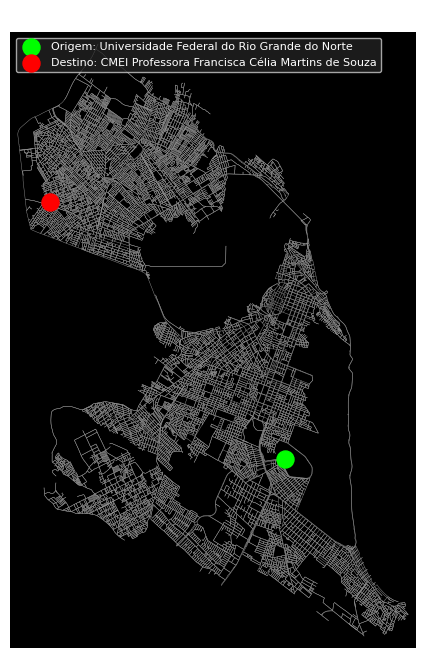

In [16]:
# ── Defina aqui os endereços ─────────────────────────────────────────

# O endereço de destino é um lugar na zona norte da Cidade Escolhido justamente por esta em um ponto muito distante da origem
ENDERECO_ORIGEM  = "Universidade Federal do Rio Grande do Norte, Natal, RN, Brazil"
ENDERECO_DESTINO = "CMEI Professora Francisca Célia Martins de Souza, Natal, RN, Brazil"

# ─────────────────────────────────────────────────────────────────────

def geocodificar(endereco):
    """
    Converte um endereço em texto para (latitude, longitude)
    usando o Nominatim via OSMnx.
    Lança ValueError se o endereço não for encontrado.
    """
    ponto = ox.geocode(endereco)
    if ponto is None:
        raise ValueError(f"Endereço não encontrado: '{endereco}'")
    return ponto  # (lat, lon)


def endereco_para_no(G, endereco):
    """
    Geocodifica o endereço e retorna o nó do grafo G mais próximo.
    """
    lat, lon = geocodificar(endereco)
    no = ox.distance.nearest_nodes(G, X=lon, Y=lat)
    return no, lat, lon


# Geocodificar origem e destino
print(f"Geocodificando origem:  '{ENDERECO_ORIGEM}'...")
origem,  lat_orig,  lon_orig  = endereco_para_no(G, ENDERECO_ORIGEM)

print(f"Geocodificando destino: '{ENDERECO_DESTINO}'...")
destino, lat_dest,  lon_dest  = endereco_para_no(G, ENDERECO_DESTINO)

print(f"\nOrigem  (A): nó {origem}  — lat={lat_orig:.6f}, lon={lon_orig:.6f}")
print(f"Destino (B): nó {destino} — lat={lat_dest:.6f}, lon={lon_dest:.6f}")

if origem == destino:
    raise ValueError("Origem e destino resultaram no mesmo nó. Use endereços mais distantes.")

# ── Visualização ─────────────────────────────────────────────────────────
ox_fig, ox_ax = ox.plot_graph(
    G, node_size=0, edge_linewidth=0.3,
    show=False, close=False, bgcolor='k'
)

ox_ax.scatter(lon_orig,  lat_orig,  c='lime', s=150, zorder=5, label=f'Origem: {ENDERECO_ORIGEM.split(",")[0]}')
ox_ax.scatter(lon_dest,  lat_dest,  c='red',  s=150, zorder=5, label=f'Destino: {ENDERECO_DESTINO.split(",")[0]}')
ox_ax.legend(loc='upper left', fontsize=8, facecolor='#222', labelcolor='white')
plt.title("Grafo de Natal — Origem e Destino", color='white')
plt.show()


## 6. Implementação dos Algoritmos de Caminho Mínimo

Os quatro algoritmos exigidos são implementados sobre o grafo NetworkX
usando o atributo `weight` como parâmetro, o que permite reutilizá-los
com qualquer função de custo (`length`, `travel_time`, `traffic_time`).

### 6.1 Dijkstra Simples (sem heap — O(V²))


In [17]:
def dijkstra_simples(G, source, weight="length"):
    """
    Dijkstra sem fila de prioridade (O(V²)).
    Retorna (dist, prev) onde:
      dist[v] = menor custo de source até v
      prev[v] = nó anterior no caminho mínimo
    """
    dist = {n: float("inf") for n in G.nodes}
    prev = {n: None for n in G.nodes}
    dist[source] = 0.0
    unvisited = set(G.nodes)

    while unvisited:
        # Seleciona o nó não visitado com menor distância (O(V))
        u = min(unvisited, key=lambda n: dist[n])
        if dist[u] == float("inf"):
            break
        unvisited.remove(u)

        for v, edge_data in G[u].items():
            # Pega o menor peso entre as arestas paralelas (MultiDiGraph)
            w = min(d.get(weight, float("inf")) for d in edge_data.values())
            alt = dist[u] + w
            if alt < dist[v]:
                dist[v] = alt
                prev[v] = u

    return dist, prev


def reconstruir_caminho(prev, source, target):
    """Reconstrói o caminho de source até target a partir do dicionário prev."""
    caminho = []
    no = target
    while no is not None:
        caminho.append(no)
        no = prev[no]
        if caminho and caminho[-1] == source:
            break
    caminho.reverse()
    if not caminho or caminho[0] != source:
        return []
    return caminho


print("Dijkstra simples definido.")


Dijkstra simples definido.


### 6.2 Dijkstra com Heap (O((V + E) log V))

In [18]:
def dijkstra_heap(G, source, weight="length"):
    """
    Dijkstra com fila de prioridade (min-heap) — O((V+E) log V).
    """
    dist = {n: float("inf") for n in G.nodes}
    prev = {n: None for n in G.nodes}
    dist[source] = 0.0
    heap = [(0.0, source)]  # (custo, nó)

    while heap:
        custo_u, u = heapq.heappop(heap)
        if custo_u > dist[u]:
            continue  # entrada desatualizada

        for v, edge_data in G[u].items():
            w = min(d.get(weight, float("inf")) for d in edge_data.values())
            alt = dist[u] + w
            if alt < dist[v]:
                dist[v] = alt
                prev[v] = u
                heapq.heappush(heap, (alt, v))

    return dist, prev


print("Dijkstra com Heap definido.")


Dijkstra com Heap definido.


### 6.3 A* com Heurística Geográfica

A heurística é a **distância Haversine** (distância real em linha reta
entre dois pontos geográficos), que é admissível pois nunca superestima
o custo real (`length` em metros).


In [19]:
def haversine(lat1, lon1, lat2, lon2):
    """Distância em metros entre dois pontos geográficos (heurística admissível)."""
    R = 6_371_000  # raio da Terra em metros
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlam / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


def a_star(G, source, target, weight="length"):
    """
    A* com heurística geográfica (Haversine).
    Retorna (dist, prev, nos_expandidos).
    """
    t_lat = G.nodes[target]["y"]
    t_lon = G.nodes[target]["x"]

    dist = {n: float("inf") for n in G.nodes}
    prev = {n: None for n in G.nodes}
    dist[source] = 0.0
    nos_expandidos = 0

    # heap: (f = g + h, g, nó)
    heap = [(haversine(G.nodes[source]["y"], G.nodes[source]["x"], t_lat, t_lon), 0.0, source)]

    while heap:
        f, g, u = heapq.heappop(heap)
        if g > dist[u]:
            continue
        nos_expandidos += 1
        if u == target:
            break

        for v, edge_data in G[u].items():
            w = min(d.get(weight, float("inf")) for d in edge_data.values())
            g_new = dist[u] + w
            if g_new < dist[v]:
                dist[v] = g_new
                prev[v] = u
                h = haversine(G.nodes[v]["y"], G.nodes[v]["x"], t_lat, t_lon)
                heapq.heappush(heap, (g_new + h, g_new, v))

    return dist, prev, nos_expandidos


print("A* definido.")


A* definido.


### 6.4 Algoritmo Adicional: Bellman-Ford

O **Bellman-Ford** resolve o problema de caminho mínimo com complexidade
O(V × E). Diferente do Dijkstra, suporta pesos negativos, embora aqui
os pesos sejam sempre positivos. É útil como referência de corretude e
para grafos com características adversas. Relaxa todas as arestas V−1
vezes, garantindo a convergência ao caminho ótimo.


In [20]:
def bellman_ford(G, source, weight="length"):
    """
    Bellman-Ford — O(V × E).
    Retorna (dist, prev). Detecta ciclos negativos se existirem.
    """
    dist = {n: float("inf") for n in G.nodes}
    prev = {n: None for n in G.nodes}
    dist[source] = 0.0

    nodes = list(G.nodes)
    V = len(nodes)

    for _ in range(V - 1):
        atualizado = False
        for u, v, data in G.edges(data=True):
            w = data.get(weight, float("inf"))
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                prev[v] = u
                atualizado = True
        if not atualizado:
            break  # convergência antecipada

    # Verificação de ciclo negativo (não esperado neste problema)
    for u, v, data in G.edges(data=True):
        w = data.get(weight, float("inf"))
        if dist[u] + w < dist[v]:
            print("AVISO: ciclo negativo detectado!")
            break

    return dist, prev


print("Bellman-Ford definido.")


Bellman-Ford definido.


## 7. Lógica Central: Seleção do Ponto de Embarque

O usuário informa a distância máxima de caminhada `X` (em metros).
O algoritmo:
1. Filtra todos os pontos de embarque de carro (`pickup_nodes`) a ≤ X metros a pé da origem.
2. Para cada candidato `P`, calcula o custo total `A→P (a pé) + P→B (carro)`.
3. Escolhe o `P` com menor custo total.

O ponto `P` representa onde o usuário embarca em um táxi ou veículo
de ride-sharing para completar o trajeto até o destino `B`.


In [21]:
# Grafo pedestre (para calcular caminhada A→P)
G_walk = ox.graph_from_place(place, network_type='walk')
G_walk = ox.add_edge_speeds(G_walk)
G_walk = ox.add_edge_travel_times(G_walk)

print("Grafo pedestre carregado.")


Grafo pedestre carregado.


In [22]:
def encontrar_melhor_embarque(origem, destino, pickup_nodes, max_walk_m,
                               weight_walk="length", weight_drive="length",
                               G_drive=G, G_ped=G_walk):
    """
    Retorna dict com o melhor ponto P e os dados da rota completa.
    pickup_nodes: lista de nós candidatos a ponto de embarque de carro.
    Usa Dijkstra com Heap para eficiência.
    """
    # Pré-calcula distâncias a partir da origem no grafo pedestre
    dist_walk, prev_walk = dijkstra_heap(G_ped, origem, weight=weight_walk)

    candidatos = [p for p in pickup_nodes if dist_walk.get(p, float("inf")) <= max_walk_m]
    if not candidatos:
        return None  # nenhum ponto alcançável a pé

    melhor = None
    melhor_custo = float("inf")

    for P in candidatos:
        custo_caminhada = dist_walk[P]

        # Carro de P até B
        dist_drive, _ = dijkstra_heap(G_drive, P, weight=weight_drive)
        custo_carro = dist_drive.get(destino, float("inf"))

        custo_total = custo_caminhada + custo_carro
        if custo_total < melhor_custo:
            melhor_custo = custo_total
            melhor = {
                "P": P,
                "custo_caminhada": custo_caminhada,
                "custo_carro": custo_carro,
                "custo_total": custo_total,
                "prev_walk": prev_walk,
            }

    return melhor


MAX_WALK_METROS = 500  # ajuste conforme necessário
resultado = encontrar_melhor_embarque(origem, destino, pickup_nodes, MAX_WALK_METROS)

if resultado:
    print(f"Melhor ponto de embarque P: {resultado['P']}")
    print(f"  Caminhada A→P: {resultado['custo_caminhada']:.1f} m")
    print(f"  Carro    P→B: {resultado['custo_carro']:.1f} m")
    print(f"  Total:        {resultado['custo_total']:.1f} m")
else:
    print(f"Nenhum ponto de embarque a menos de {MAX_WALK_METROS} m da origem.")


Melhor ponto de embarque P: 1387156495
  Caminhada A→P: 431.2 m
  Carro    P→B: 16234.2 m
  Total:        16665.5 m


## 8. Comparação dos 5 Cenários Exigidos

| # | Cenário | Peso usado |
|---|---------|-----------|
| 1 | Menor distância total | `length` |
| 2 | Mais rápido sem trânsito | `travel_time` |
| 3 | Mais rápido com trânsito sintético | `traffic_time` |
| 4 | Sem caminhada (carro direto A→B) | `length` / `travel_time` |
| 5 | Ganho ao caminhar até outro ponto | comparação entre P ótimo e P=origem |


In [23]:
def cenario(label, weight_walk, weight_drive, G_drive=G, G_ped=G_walk,
             max_walk=MAX_WALK_METROS):
    t0 = time.perf_counter()
    res = encontrar_melhor_embarque(origem, destino, pickup_nodes, max_walk,
                                    weight_walk=weight_walk,
                                    weight_drive=weight_drive,
                                    G_drive=G_drive, G_ped=G_ped)
    elapsed = time.perf_counter() - t0
    if res:
        print(f"\n{'─'*55}")
        print(f"Cenário: {label}")
        print(f"  P = {res['P']}")
        print(f"  Caminhada ({weight_walk}): {res['custo_caminhada']:.2f}")
        print(f"  Carro     ({weight_drive}): {res['custo_carro']:.2f}")
        print(f"  Total:    {res['custo_total']:.2f}")
        print(f"  Tempo de execução: {elapsed:.3f} s")
    else:
        print(f"\nCenário {label}: sem candidatos a {max_walk} m")
    return res, elapsed

# ── Cenário 1: menor distância
c1, t1 = cenario("1 — Menor distância (length)", "length", "length")

# ── Cenário 2: mais rápido sem trânsito
c2, t2 = cenario("2 — Mais rápido sem trânsito (travel_time)", "travel_time", "travel_time")

# ── Cenário 3: mais rápido com trânsito sintético
c3, t3 = cenario("3 — Mais rápido com trânsito sintético (traffic_time)", "travel_time", "traffic_time")

# ── Cenário 4: sem caminhada — rota direta A→B de carro
t0 = time.perf_counter()
dist_direto, prev_direto = dijkstra_heap(G, origem, weight="length")
t4 = time.perf_counter() - t0
custo_direto = dist_direto.get(destino, float("inf"))
print(f"\n{'─'*55}")
print(f"Cenário 4 — Sem caminhada (carro direto A→B)")
print(f"  Distância: {custo_direto:.2f} m")
print(f"  Tempo de execução: {t4:.3f} s")

# ── Cenário 5: ganho ao caminhar
if c1 and custo_direto != float("inf"):
    ganho = custo_direto - c1["custo_total"]
    print(f"\n{'─'*55}")
    print(f"Cenário 5 — Ganho ao caminhar até P ótimo")
    print(f"  Rota direta:     {custo_direto:.2f} m")
    print(f"  Com caminhada:   {c1['custo_total']:.2f} m")
    print(f"  Ganho:           {ganho:.2f} m ({'positivo ✓' if ganho > 0 else 'negativo — caminhar não compensa'})")



───────────────────────────────────────────────────────
Cenário: 1 — Menor distância (length)
  P = 1387156495
  Caminhada (length): 431.22
  Carro     (length): 16234.23
  Total:    16665.45
  Tempo de execução: 0.473 s

───────────────────────────────────────────────────────
Cenário: 2 — Mais rápido sem trânsito (travel_time)
  P = 504799324
  Caminhada (travel_time): 195.26
  Carro     (travel_time): 850.02
  Total:    1045.28
  Tempo de execução: 71.631 s

Cenário 3 — Mais rápido com trânsito sintético (traffic_time): sem candidatos a 500 m

───────────────────────────────────────────────────────
Cenário 4 — Sem caminhada (carro direto A→B)
  Distância: 15205.38 m
  Tempo de execução: 0.240 s

───────────────────────────────────────────────────────
Cenário 5 — Ganho ao caminhar até P ótimo
  Rota direta:     15205.38 m
  Com caminhada:   16665.45 m
  Ganho:           -1460.07 m (negativo — caminhar não compensa)


## 9. Comparação de Algoritmos (mesma consulta, 4 implementações)

Executamos os 4 algoritmos na mesma rota `origem → destino` com peso
`length` e medimos:
- distância encontrada (devem ser iguais — validação de corretude);
- nós expandidos (quando disponível);
- tempo de execução.


In [24]:
resultados = {}

# ─ Dijkstra Simples ─
# AVISO: lento em grafos grandes — pode demorar vários minutos
print("Rodando Dijkstra Simples... (pode ser lento)")
t0 = time.perf_counter()
dist_s, prev_s = dijkstra_simples(G, origem, weight="length")
resultados["Dijkstra Simples"] = {
    "dist": dist_s.get(destino, float("inf")),
    "tempo": time.perf_counter() - t0,
    "nos_expandidos": "N/A"
}
print(f"  ✓ {resultados['Dijkstra Simples']['dist']:.1f} m em {resultados['Dijkstra Simples']['tempo']:.3f} s")

# ─ Dijkstra com Heap ─
t0 = time.perf_counter()
dist_h, prev_h = dijkstra_heap(G, origem, weight="length")
resultados["Dijkstra Heap"] = {
    "dist": dist_h.get(destino, float("inf")),
    "tempo": time.perf_counter() - t0,
    "nos_expandidos": "N/A"
}
print(f"  ✓ {resultados['Dijkstra Heap']['dist']:.1f} m em {resultados['Dijkstra Heap']['tempo']:.3f} s")

# ─ A* ─
t0 = time.perf_counter()
dist_a, prev_a, nos_a = a_star(G, origem, destino, weight="length")
resultados["A*"] = {
    "dist": dist_a.get(destino, float("inf")),
    "tempo": time.perf_counter() - t0,
    "nos_expandidos": nos_a
}
print(f"  ✓ {resultados['A*']['dist']:.1f} m em {resultados['A*']['tempo']:.3f} s | nós expandidos: {nos_a}")

# ─ Bellman-Ford (apenas em subgrafo menor por performance) ─
print("Rodando Bellman-Ford (subgrafo próximo à origem)...")
ego = nx.ego_graph(G, origem, radius=1000, distance="length")
t0 = time.perf_counter()
if destino in ego.nodes:
    dist_bf, _ = bellman_ford(ego, origem, weight="length")
    dist_bf_val = dist_bf.get(destino, float("inf"))
else:
    dist_bf_val = float("inf")
resultados["Bellman-Ford*"] = {
    "dist": dist_bf_val,
    "tempo": time.perf_counter() - t0,
    "nos_expandidos": "N/A"
}
print(f"  ✓ {dist_bf_val:.1f} m em {resultados['Bellman-Ford*']['tempo']:.3f} s")
print("  * Bellman-Ford executado em subgrafo local (raio 1 km) por eficiência.")

# ── Tabela comparativa ──
print(f"\n{'Algoritmo':<22} {'Distância (m)':>15} {'Tempo (s)':>12} {'Nós Expandidos':>16}")
print("─" * 68)
for nome, r in resultados.items():
    d = f"{r['dist']:.1f}" if r['dist'] != float("inf") else "∞"
    print(f"{nome:<22} {d:>15} {r['tempo']:>12.4f} {str(r['nos_expandidos']):>16}")


Rodando Dijkstra Simples... (pode ser lento)
  ✓ 15205.4 m em 32.036 s
  ✓ 15205.4 m em 0.204 s
  ✓ 15205.4 m em 0.099 s | nós expandidos: 5341
Rodando Bellman-Ford (subgrafo próximo à origem)...
  ✓ inf m em 0.000 s
  * Bellman-Ford executado em subgrafo local (raio 1 km) por eficiência.

Algoritmo                Distância (m)    Tempo (s)   Nós Expandidos
────────────────────────────────────────────────────────────────────
Dijkstra Simples               15205.4      32.0362              N/A
Dijkstra Heap                  15205.4       0.2045              N/A
A*                             15205.4       0.0986             5341
Bellman-Ford*                        ∞       0.0002              N/A


## 10. Visualização das Rotas

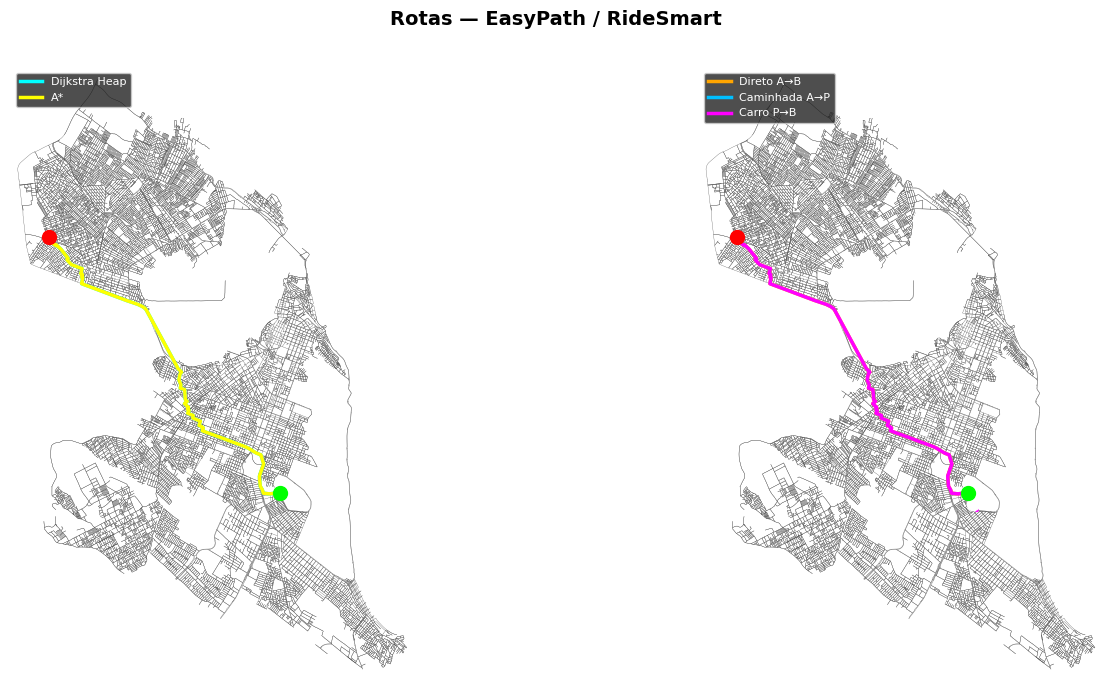

Figura salva como rotas_ridesmart.png


In [25]:
def plotar_rota(G, prev, source, target, ax, color, label, weight="length"):
    """Plota um caminho reconstruído sobre um eixo matplotlib existente."""
    caminho = reconstruir_caminho(prev, source, target)
    if not caminho:
        print(f"Caminho não encontrado para '{label}'")
        return
    xs = [G.nodes[n]["x"] for n in caminho]
    ys = [G.nodes[n]["y"] for n in caminho]
    ax.plot(xs, ys, color=color, linewidth=2.5, label=label, zorder=4)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Rotas — EasyPath / RideSmart", fontsize=14, fontweight="bold")

for ax in axes:
    ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.2,
                  edge_color="#444444", bgcolor="k", show=False, close=False)

# Painel esquerdo: Dijkstra Heap vs A*
ax = axes[0]
ax.set_title("Dijkstra Heap vs A*", color="white")
plotar_rota(G, prev_h, origem, destino, ax, "cyan",  "Dijkstra Heap")
plotar_rota(G, prev_a, origem, destino, ax, "yellow", "A*")
ax.scatter(G.nodes[origem]["x"],  G.nodes[origem]["y"],  c="lime", s=100, zorder=6)
ax.scatter(G.nodes[destino]["x"], G.nodes[destino]["y"], c="red",  s=100, zorder=6)
ax.legend(loc="upper left", fontsize=8, facecolor="#222", labelcolor="white")

# Painel direito: Sem caminhada vs Com caminhada (cenário 1)
ax = axes[1]
ax.set_title("Direto (A→B) vs Com Embarque (A→P→B)", color="white")
plotar_rota(G, prev_direto, origem, destino, ax, "orange", "Direto A→B")
if c1:
    P = c1["P"]
    plotar_rota(G_walk, c1["prev_walk"], origem, P, ax, "deepskyblue", "Caminhada A→P")
    dist_p, prev_p = dijkstra_heap(G, P, weight="length")
    plotar_rota(G, prev_p, P, destino, ax, "magenta", "Carro P→B")
    ax.scatter(G.nodes[P]["x"], G.nodes[P]["y"], c="white", s=80, zorder=6)
ax.scatter(G.nodes[origem]["x"],  G.nodes[origem]["y"],  c="lime", s=100, zorder=6)
ax.scatter(G.nodes[destino]["x"], G.nodes[destino]["y"], c="red",  s=100, zorder=6)
ax.legend(loc="upper left", fontsize=8, facecolor="#222", labelcolor="white")

plt.tight_layout()
plt.savefig("rotas_ridesmart.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figura salva como rotas_ridesmart.png")


## 13. Comparação Visual com Zoom: A→P (caminhada) + P→B (carro) por Algoritmo

Para visualizar com clareza o trajeto completo (caminhada até o ponto de
embarque + trecho de carro), recortamos um subgrafo local em torno de P
(grande o suficiente para conter B) e rodamos os 4 algoritmos a partir
desse ponto. Isso torna viável rodar Dijkstra Simples e Bellman-Ford
em tempo hábil, já que a comparação de eficiência em escala já foi feita
na Seção 9.

Subgrafo local: 18558 nós (grafo completo tinha 18585)
Raio usado: 21104 m

Rodando os 4 algoritmos no subgrafo local...
  Dijkstra Simples: 16234.2 m (24.430s)
  Dijkstra Heap:    16234.2 m (0.199s)
  A*:               16234.2 m (0.080s | nós expandidos: 5591)
  Bellman-Ford:     16234.2 m (11.430s)

Todos os algoritmos concordam? True


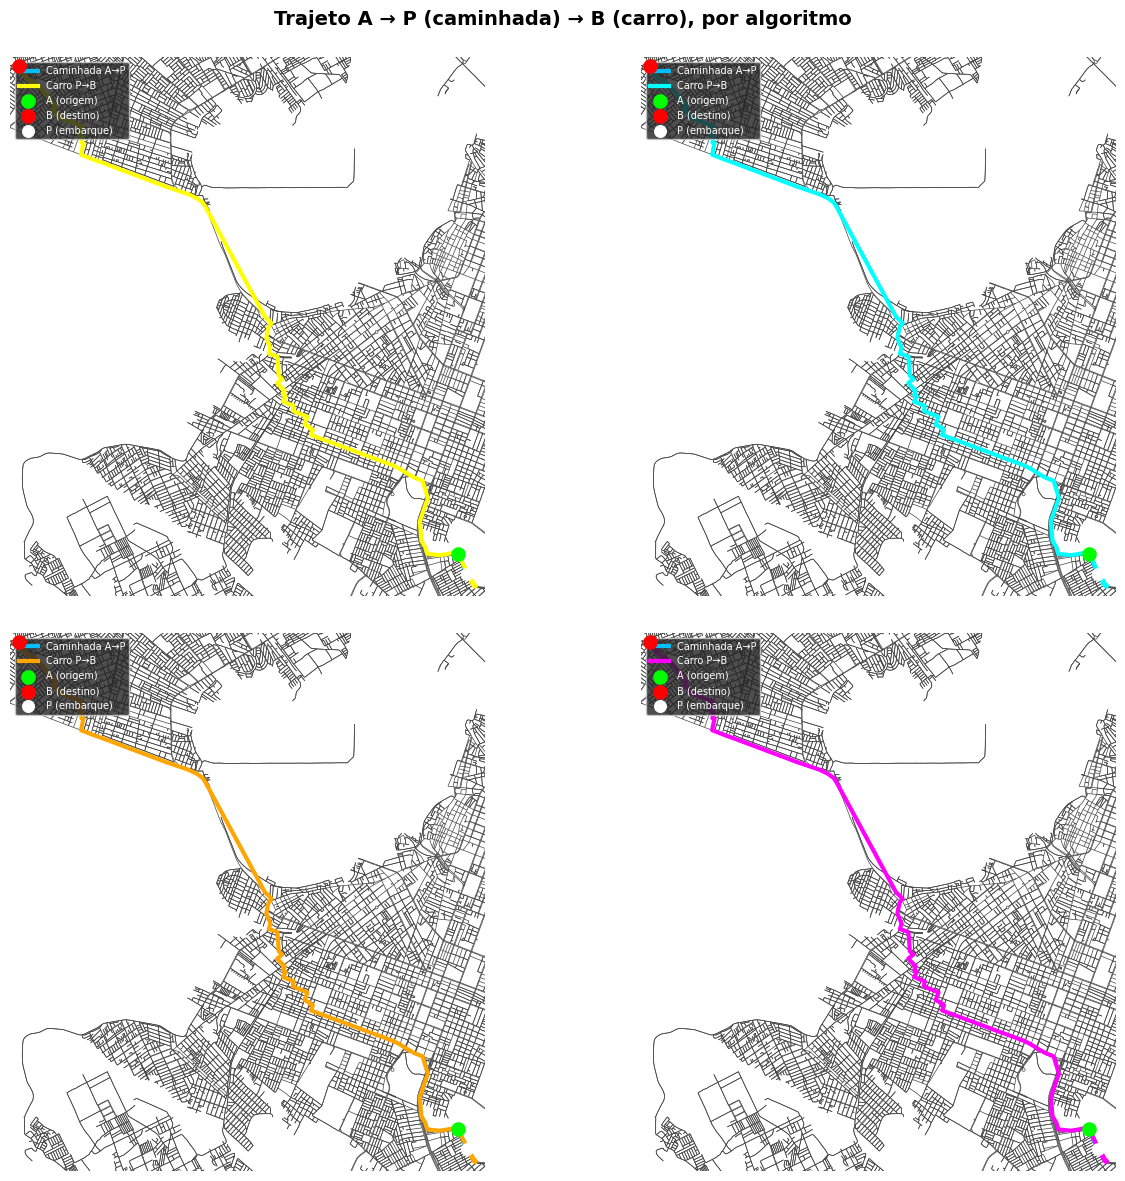

Figura salva como rotas_zoom_4algoritmos.png


In [26]:
# ============================================================
# 13. Comparação Visual com Zoom: A→P + P→B, 4 algoritmos
# ============================================================

P = c1["P"]  # ponto de embarque ótimo (Cenário 1)

# ── 1. Recortar subgrafo local em torno de P, garantindo que B esteja dentro ──
raio_sub = c1["custo_carro"] * 1.3  # folga de 30% sobre a distância P->B
G_sub = nx.ego_graph(G, P, radius=raio_sub, distance="length")

while destino not in G_sub.nodes:
    raio_sub *= 1.5
    G_sub = nx.ego_graph(G, P, radius=raio_sub, distance="length")

print(f"Subgrafo local: {G_sub.number_of_nodes()} nós "
      f"(grafo completo tinha {G.number_of_nodes()})")
print(f"Raio usado: {raio_sub:.0f} m\n")

# ── 2. Rodar os 4 algoritmos a partir de P, dentro do subgrafo ──
print("Rodando os 4 algoritmos no subgrafo local...")

t0 = time.perf_counter()
dist_s_P, prev_s_P = dijkstra_simples(G_sub, P, weight="length")
print(f"  Dijkstra Simples: {dist_s_P.get(destino, float('inf')):.1f} m "
      f"({time.perf_counter()-t0:.3f}s)")

t0 = time.perf_counter()
dist_h_P, prev_h_P = dijkstra_heap(G_sub, P, weight="length")
print(f"  Dijkstra Heap:    {dist_h_P.get(destino, float('inf')):.1f} m "
      f"({time.perf_counter()-t0:.3f}s)")

t0 = time.perf_counter()
dist_a_P, prev_a_P, nos_a_P = a_star(G_sub, P, destino, weight="length")
print(f"  A*:               {dist_a_P.get(destino, float('inf')):.1f} m "
      f"({time.perf_counter()-t0:.3f}s | nós expandidos: {nos_a_P})")

t0 = time.perf_counter()
dist_bf_P, prev_bf_P = bellman_ford(G_sub, P, weight="length")
print(f"  Bellman-Ford:     {dist_bf_P.get(destino, float('inf')):.1f} m "
      f"({time.perf_counter()-t0:.3f}s)")

# Verificação de corretude: todos encontraram o mesmo custo?
custos = [dist_s_P[destino], dist_h_P[destino], dist_a_P[destino], dist_bf_P[destino]]
print(f"\nTodos os algoritmos concordam? {all(abs(c - custos[0]) < 1e-6 for c in custos)}")


# ── 3. Funções auxiliares de plot com zoom ──
def coordenadas_caminho(Grafo, caminho):
    xs = [Grafo.nodes[n]["x"] for n in caminho]
    ys = [Grafo.nodes[n]["y"] for n in caminho]
    return xs, ys


def plotar_rota_zoom(ax, prev_drive, algoritmo_nome, cor_carro, margem=0.0015):
    caminho_walk  = reconstruir_caminho(c1["prev_walk"], origem, P)
    caminho_drive = reconstruir_caminho(prev_drive, P, destino)

    if not caminho_drive:
        ax.set_title(f"{algoritmo_nome}\n(rota P→B não encontrada)", color="white")
        ax.axis("off")
        return

    # Fundo: grafo local recortado (apenas para contexto visual)
    ox.plot_graph(G_sub, ax=ax, node_size=0, edge_linewidth=0.5,
                   edge_color="#444444", bgcolor="k", show=False, close=False)

    # Trecho a pé (A -> P)
    xs_w, ys_w = coordenadas_caminho(G_walk, caminho_walk) if caminho_walk else ([], [])
    if xs_w:
        ax.plot(xs_w, ys_w, color="deepskyblue", linewidth=3,
                label="Caminhada A→P", zorder=5)

    # Trecho de carro (P -> B)
    xs_d, ys_d = coordenadas_caminho(G_sub, caminho_drive)
    ax.plot(xs_d, ys_d, color=cor_carro, linewidth=3,
            label=f"Carro P→B", zorder=5)

    # Marcadores
    ax.scatter(G.nodes[origem]["x"],  G.nodes[origem]["y"],  c="lime",  s=90, zorder=6, label="A (origem)")
    ax.scatter(G.nodes[destino]["x"], G.nodes[destino]["y"], c="red",   s=90, zorder=6, label="B (destino)")
    ax.scatter(G.nodes[P]["x"],       G.nodes[P]["y"],       c="white", s=70, zorder=6, label="P (embarque)")

    # Zoom: bounding box do trajeto completo, com margem
    todas_xs = xs_w + xs_d
    todas_ys = ys_w + ys_d
    ax.set_xlim(min(todas_xs) - margem, max(todas_xs) + margem)
    ax.set_ylim(min(todas_ys) - margem, max(todas_ys) + margem)

    ax.set_title(algoritmo_nome, color="white", fontsize=12, fontweight="bold")
    ax.legend(loc="upper left", fontsize=7, facecolor="#222", labelcolor="white")


# ── 4. Figura 2x2: um painel por algoritmo ──
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Trajeto A → P (caminhada) → B (carro), por algoritmo",
              fontsize=14, fontweight="bold")

plotar_rota_zoom(axes[0, 0], prev_s_P,  "Dijkstra Simples", "yellow")
plotar_rota_zoom(axes[0, 1], prev_h_P,  "Dijkstra Heap",    "cyan")
plotar_rota_zoom(axes[1, 0], prev_a_P,  "A*",               "orange")
plotar_rota_zoom(axes[1, 1], prev_bf_P, "Bellman-Ford",     "magenta")

plt.tight_layout()
plt.savefig("rotas_zoom_4algoritmos.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figura salva como rotas_zoom_4algoritmos.png")

## 12. Referências

- Boeing, G. (2017). OSMnx: New methods for acquiring, constructing, analyzing, and visualizing complex street networks. *Computers, Environment and Urban Systems*, 65, 126-139.
- Cormen, T. H. et al. (2009). *Introduction to Algorithms* (3rd ed.). MIT Press.
- Hart, P. E., Nilsson, N. J., & Raphael, B. (1968). A formal basis for the heuristic determination of minimum cost paths. *IEEE Transactions on Systems Science and Cybernetics*, 4(2), 100-107.
- Bellman, R. (1958). On a routing problem. *Quarterly of Applied Mathematics*, 16(1), 87-90.
